# NOAA Workflow - cloud_total
Download and inspect NOAA GFS data for this map type.

In [1]:
from datetime import date
from pathlib import Path
import json
import sys

ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(ROOT / 'scripts'))

from noaa_map_pipeline import download_map_dataset, analyze_data_folder, MAP_SPECS

MAP_TYPE = 'cloud_total'
RUN_DATE = date(2026, 4, 6)
RUN_HOUR = 0
BASE_DIR = str(ROOT)

MAP_SPECS[MAP_TYPE]

MapSpec(map_type='cloud_total', description='TCDC entire atmosphere', products=[Product(name='tcdc_entire_atmosphere', query={'lev_entire_atmosphere': 'on', 'var_TCDC': 'on'})], fff_segments_full=[(0, 0, 1)])

In [2]:
manifest = download_map_dataset(
    map_type=MAP_TYPE,
    run_date=RUN_DATE,
    run_hour=RUN_HOUR,
    base_dir=BASE_DIR,
    mode='init_only',  # change to 'full' for full timeline
    rpm_limit=60,
)
summary = analyze_data_folder(BASE_DIR, MAP_TYPE)
print('Downloads:', len(manifest['downloads']))
print(json.dumps(summary, indent=2)[:1200])

Download cloud_total: 1/1 (100.00%) | ETA 00:00 | fff=000 product=tcdc_entire_atmosphere status=skipped_existing
Downloads: 1
{
  "map_type": "cloud_total",
  "file_count": 209,
  "total_size_mb": 336.796,
  "fff_available": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18,
    19,
    20,
    21,
    22,
    23,
    24,
    25,
    26,
    27,
    28,
    29,
    30,
    31,
    32,
    33,
    34,
    35,
    36,
    37,
    38,
    39,
    40,
    41,
    42,
    43,
    44,
    45,
    46,
    47,
    48,
    49,
    50,
    51,
    52,
    53,
    54,
    55,
    56,
    57,
    58,
    59,
    60,
    61,
    62,
    63,
    64,
    65,
    66,
    67,
    68,
    69,
    70,
    71,
    72,
    73,
    74,
    75,
    76,
    77,
    78,
    79,
    80,
    81,
    82,
    83,
    84,
    85,
    86,
    87,
    88,
    89,
    90,
    91,
    92,
    93,
    94,
    95,
    96,
    97,

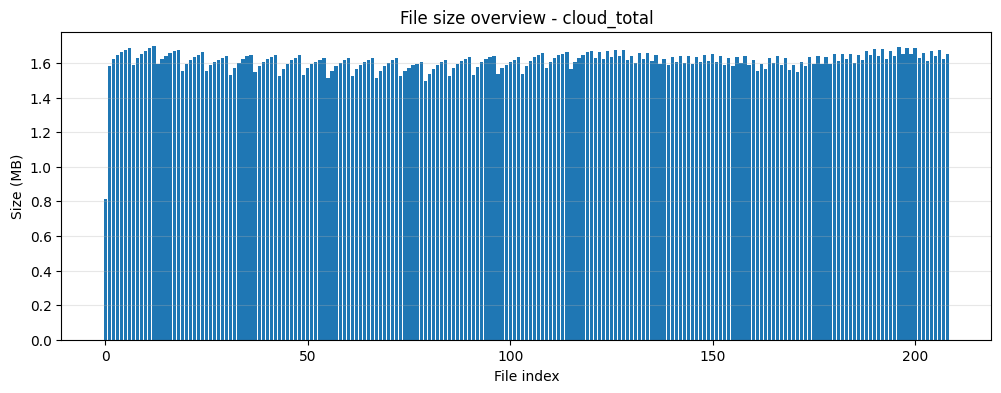

In [3]:
try:
    import matplotlib.pyplot as plt
    files = summary['files']
    names = [f['file'] for f in files]
    sizes_mb = [round(f['size_bytes'] / (1024 * 1024), 3) for f in files]

    plt.figure(figsize=(12, 4))
    plt.bar(range(len(names)), sizes_mb)
    plt.title(f'File size overview - {MAP_TYPE}')
    plt.xlabel('File index')
    plt.ylabel('Size (MB)')
    plt.grid(axis='y', alpha=0.3)
    plt.show()
except Exception as exc:
    print('Matplotlib plot skipped:', exc)

In [4]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parents[1]
if str(ROOT / "scripts") not in sys.path:
    sys.path.append(str(ROOT / "scripts"))

from map_visualization import visualize_map_type

map_type = globals().get("MAP_TYPE", Path.cwd().resolve().name)
figures = visualize_map_type(
    base_dir=str(ROOT),
    map_type=map_type,
    downsample=4,
    max_frames=80,
)
print(f"Rendered {len(figures)} slider figure(s) for {map_type}.")

Skip gfs.t00z.pgrb2.0p25.f001.tcdc_entire_atmosphere.grib2: multiple values for unique key, try re-open the file with one of:
    filter_by_keys={'stepType': 'instant'}
    filter_by_keys={'stepType': 'avg'}
Skip gfs.t00z.pgrb2.0p25.f002.tcdc_entire_atmosphere.grib2: multiple values for unique key, try re-open the file with one of:
    filter_by_keys={'stepType': 'instant'}
    filter_by_keys={'stepType': 'avg'}
Skip gfs.t00z.pgrb2.0p25.f003.tcdc_entire_atmosphere.grib2: multiple values for unique key, try re-open the file with one of:
    filter_by_keys={'stepType': 'instant'}
    filter_by_keys={'stepType': 'avg'}
Skip gfs.t00z.pgrb2.0p25.f004.tcdc_entire_atmosphere.grib2: multiple values for unique key, try re-open the file with one of:
    filter_by_keys={'stepType': 'instant'}
    filter_by_keys={'stepType': 'avg'}
Skip gfs.t00z.pgrb2.0p25.f005.tcdc_entire_atmosphere.grib2: multiple values for unique key, try re-open the file with one of:
    filter_by_keys={'stepType': 'instant'}

Rendered 1 slider figure(s) for cloud_total.
